# Working with Gridded netCDF data and xarray

**This lesson is based on the [_Lesson: working with netCDF data_](https://fabienmaussion.info/climate_system/week_02/01_Lesson_NetCDF_Data.html) in [Fabien Maussion](https://fabienmaussion.info/)'s Physics of the Climate System Course.** 

_These lecture notes and exercises are licensed under a [Creative Commons Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) license._ 

You already learned how to use the basic features of the python language with the numpy and matplotlib libraries. The purpose of this lesson is to introduce you to the main tool that you will use for working with gridded data: [xarray](http://xarray.pydata.org).

This is a dense lesson. Please do it entirely and try to remember its structure and content. This code will provide a template for your own code, and you can always come back to these examples when you'll need them. I don't expect you to understand all details, but I hope that you are going to get acquainted with the "xarray way" of manipulating multi-dimensional data. You will have to copy and adapt parts of the code below to complete the exercises.

## Learning Objectives 

- Describe netCDF files as self-describing data
- Understand how netCDF can be applied to big data 
- Load netCDF datasets
- Select data by time and coordinates
- Perform aggregation operations
- Plot variables

## NetCDF Files

In order to open and plot NetCDF files, you'll need to install the `xarray`, `cartopy`, and `netcdf4` packages: if you haven't done so already, follow the [installation instructions](https://isat-drg.github.io/ISAT_420/EnvironmentalData/4_Environments/condaEnvs.html) for our ISAT420 python environment that contains these packages. 

As a quick fix, you can also install them directly using the code below (this will take some time). 


In [1]:
#To install these packages remove the hash (#) characters in the lines below and run the cell. The ! tells jupyter to run a system command. 
#! conda install xarray
#! conda install netcdf4
#! conda install cartopy 

### Imports and options

First, let's import the tools we need. Remember why we need to import our tools? If not, ask Dr. Gerken

In [2]:
# Import the tools we are going to need today:
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # numerical library
import xarray as xr  # netCDF library
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
from glob import glob
# Some defaults:
plt.rcParams['figure.figsize'] = (12, 5)  # Default plot size

### The Data 

We will also be using an example of [ERA5 Reanalysis](https://www.ecmwf.int/en/forecasts/dataset/ecmwf-reanalysis-v5) data.

ERA5 (or European ReAnalysis v5) provides global, hourly estimates of atmospheric, ocean wave, and land-surface variables at a horizontal resolution of 31\,km. Data is available from 1940 onwards both hourly and averaged to monthly. 

Reanalysis in general are the fusion of observations with a global weather model to derive a homogenous, regular-best estimate output on a grid from station based observations. 

ERA5 is produced by the [European Center for Medium Range Weather Forecasting (ECMWF)](https://www.ecmwf.int/) and can be downloaded freely (account registration required).

I have placed the data files into the `W8_Xarray_Gridded/Data` directory. 

### Read the data

Most of today's meteorological data is stored in the NetCDF format (``*.nc``). NetCDF files are binary files, which means that you can't just open them in a text editor. You need a special reader for it. Nearly all the programming languages offer an interface to NetCDF. For this course we are going to use the [xarray](http://xarray.pydata.org/en/stable/) library to read the data: 

Xarray commands are similar to pandas but not quite the same. To open a dataset ds we can use the [`.open_dataset()` method](https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html). 

Let's start with having a look at the ERA5 file, I am providing. 

In [3]:
# Here I downloaded the file in the "Data" folder which I placed in a folder close to this notebook
# The variable name "ds" stands for "dataset"
ds = xr.open_dataset(r'../data/reanalysis-era5-single-level-monthly-means_2000_T_Td_u_v_SST.nc', engine='netcdf4')

In [4]:
# Lets see what we have:
ds

<xarray.Dataset> Size: 249MB
Dimensions:     (valid_time: 12, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2000-01-01 ... 2000-12-01
    expver      (valid_time) <U4 192B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 50MB ...
    v10         (valid_time, latitude, longitude) float32 50MB ...
    d2m         (valid_time, latitude, longitude) float32 50MB ...
    t2m         (valid_time, latitude, longitude) float32 50MB ...
    sst         (valid_time, latitude, longitude) float32 50MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-11T00:20 GRIB to CDM+CF via cfgrib-0.9.1...

Each netcdf file has a data model, that is represented by xarray: 

![xarray data model](http://xarray.pydata.org/en/stable/_images/dataset-diagram.png)

The NetCDF dataset is made up of various elements: Dimensions, Coordinates, Variables, Attributes:

- the dimensions specify the number of elements of each data coordinate, their names should be understandable and specific
- the attributes provide some information about the file (metadata)
- the variables contain the actual data. In our file there are five variables. All have the dimensions [time, latitude, longitude], so we can expect an array of size [12, 721, 1440]
- the coordinates locate the data in space and time



## Working with big data

The entire ERA5 dataset is larger than 5 Petabytes. This is 5,000,000 GB. Your laptop has 8-16 GB of working memory (RAM) and even supercomputers cannot access more than a few TB of RAM. 

### Lazy execution 

When loading a dataset in Pandas, you are always reading the entire dataset into memory. Xarray, in contrast uses [_lazy indexing_ by design](https://docs.xarray.dev/en/latest/internals/internal-design.html#internal-design-lazy-indexing). This means, when opening a dataset, the dataset is not actually read into memory, but Xarray learns its internal structure. 

When we look into a variable, we can see the size, and the dtype of the underlying array, but not the actual values. This is because the values have not yet been loaded. 

Xarray only loads data, when it is asked to produce an output such as printing a value to the screen or making a plot. 

### Loading multiple files

Since big data is distributed across many files, Xarray can also treat data that is spread across multiple files as a single dataset. This is done by passing a list of files to the [.open_mfdataset method](https://xarray-test.readthedocs.io/en/latest/generated/xarray.open_mfdataset.html). 

In [5]:
files = glob(r'../Data/*.nc')
files

['../Data\\reanalysis-era5-single-level-monthly-means_2000_T_Td_u_v_SST.nc',
 '../Data\\reanalysis-era5-single-level-monthly-means_2001_T_Td_u_v_SST.nc']

In [6]:
ds = xr.open_mfdataset(files, engine='netcdf4')
ds

<xarray.Dataset> Size: 498MB
Dimensions:     (valid_time: 24, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2000-01-01 ... 2001-12-01
    expver      (valid_time) <U4 384B dask.array<chunksize=(12,), meta=np.ndarray>
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B 0
Data variables:
    u10         (valid_time, latitude, longitude) float32 100MB dask.array<chunksize=(6, 361, 720), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 100MB dask.array<chunksize=(6, 361, 720), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 100MB dask.array<chunksize=(6, 361, 720), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 100MB dask.array<chunksize=(6, 361, 720), meta=np.ndarray>
    sst         (valid_time, latitude, longitude) float32 100MB dask.array<chunksize=(6, 361, 720), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-11T00:20 GRIB to CDM+CF via cfgrib-0.9.1...

You can see that this looks just like loading a single file. 

### Coordinates 

Let's have a look at the **time** coordinate first:

(You can see that this is a similar notation to _pandas_)

In [7]:
ds['valid_time']

<xarray.DataArray 'valid_time' (valid_time: 24)> Size: 192B
array(['2000-01-01T00:00:00.000000000', '2000-02-01T00:00:00.000000000',
       '2000-03-01T00:00:00.000000000', '2000-04-01T00:00:00.000000000',
       '2000-05-01T00:00:00.000000000', '2000-06-01T00:00:00.000000000',
       '2000-07-01T00:00:00.000000000', '2000-08-01T00:00:00.000000000',
       '2000-09-01T00:00:00.000000000', '2000-10-01T00:00:00.000000000',
       '2000-11-01T00:00:00.000000000', '2000-12-01T00:00:00.000000000',
       '2001-01-01T00:00:00.000000000', '2001-02-01T00:00:00.000000000',
       '2001-03-01T00:00:00.000000000', '2001-04-01T00:00:00.000000000',
       '2001-05-01T00:00:00.000000000', '2001-06-01T00:00:00.000000000',
       '2001-07-01T00:00:00.000000000', '2001-08-01T00:00:00.000000000',
       '2001-09-01T00:00:00.000000000', '2001-10-01T00:00:00.000000000',
       '2001-11-01T00:00:00.000000000', '2001-12-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2000-01-01 ... 2001-12-01
    expver      (valid_time) <U4 384B dask.array<chunksize=(12,), meta=np.ndarray>
    number      int64 8B 0
Attributes:
    long_name:      time
    standard_name:  time

The array contains numbers 12 datetimes, they represent the months of the year. If we were to look into the ERA5 documentation, we know that these represent the average for each month during 2002.

The **location coordinates** are also self-explaining:

In [8]:
ds.longitude  # This is an alternate notation to ds['longitude] that works in pandas and xarray as long as there are not spaces

<xarray.DataArray 'longitude' (longitude: 1440)> Size: 12kB
array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02], shape=(1440,))
Coordinates:
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B 0
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

In [9]:
ds.latitude

<xarray.DataArray 'latitude' (latitude: 721)> Size: 6kB
array([ 90.  ,  89.75,  89.5 , ..., -89.5 , -89.75, -90.  ], shape=(721,))
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    number    int64 8B 0
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

**Q: what is the spatial resolution of the ERA5 data?**

### Variables 


Variables can also be accessed directly from the dataset:

In [10]:
ds.sst

<xarray.DataArray 'sst' (valid_time: 24, latitude: 721, longitude: 1440)> Size: 100MB
dask.array<concatenate, shape=(24, 721, 1440), dtype=float32, chunksize=(6, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2000-01-01 ... 2001-12-01
    expver      (valid_time) <U4 384B dask.array<chunksize=(12,), meta=np.ndarray>
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

The **attributes** of a variable are extremely important, they carry the metadata and must be specified by the data provider. Here we can read in which units the variable is defined, as well as a description of the variable (the "long_name" attribute).


**Q: what other information can we read from this printout? Explore the other data variables and see if you understand all of them.** *Note: you can expand each variable's attributes in the html display, or use the method `ds.info()` to list all vars and attributes.*

In [ ]:
# your answer here

## First Plots

Let't create a first set of plots. For example, we can quickly produce a map of SST in June. 

To do so, we have to select data based on the time coordinate using the[`.sel()` method](https://docs.xarray.dev/en/latest/user-guide/indexing.html). The resulting slice is a 2-D grid with latitude and longitude. 

In [11]:
sst_jun= ds.sst.sel(valid_time="2000-06-01")
sst_jun

<xarray.DataArray 'sst' (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<getitem, shape=(721, 1440), dtype=float32, chunksize=(361, 720), chunktype=numpy.ndarray>
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2000-06-01
    expver      <U4 16B dask.array<chunksize=(), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

We can now make a plot:

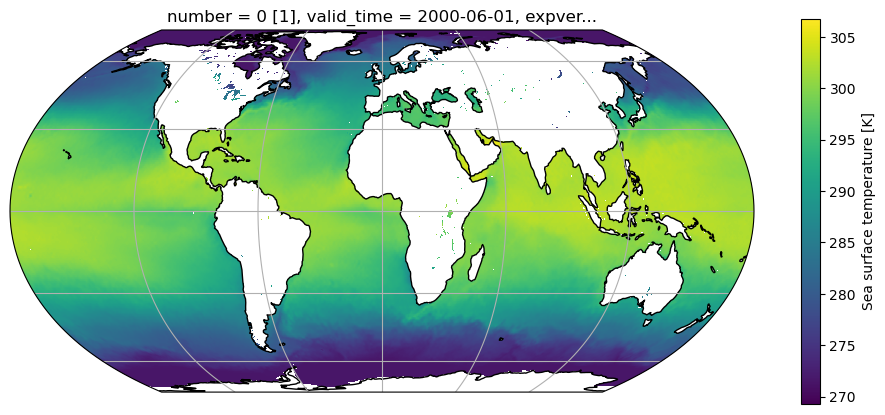

In [13]:
# Define the map projection (how does the map look like)
ax = plt.axes(projection=ccrs.EqualEarth())     
# ax is an empty plot. We now plot the variable sst_jan onto ax
sst_jun.plot(ax=ax, transform=ccrs.PlateCarree()) 
# the keyword "transform" tells the plotting function how to map the data onto a flat surface
# all projections will cause distortions, but are necessary because the world is not flat. 
ax.coastlines()
ax.gridlines(); # Add gridlines and coastlines to the plot

## Simple Analysis 

Analysing climate data is extremely easy in Python thanks to the [xarray](http://xarray.pydata.org/en/stable/) and [cartopy](https://scitools.org.uk/cartopy/docs/latest/) libraries. First we are going to compute the time average of the SST over the year:

Similar to _pandas_ we can perform computations over our data, like taking the average [`.mean()`]. We just have need to specify the dimension (`'valid_time'`, `'latitude'`, `'longitude'`).

In [14]:
sst_avg = ds.sst.mean(dim='valid_time')

What is `sst_avg` by the way?

In [15]:
sst_avg

<xarray.DataArray 'sst' (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<mean_agg-aggregate, shape=(721, 1440), dtype=float32, chunksize=(361, 720), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

So `sst_avg` is a 2-dimensional array of dimensions [latitude, longitude] (note that the time dimension has disapeared).

When we applied the `.mean()` function, we added an argument (called a **keyword argument**): ``dim='valid_time'``. With this argument, we told the function to compute the average *over the time dimension*.

Let's make another plot of this. Give it a try.

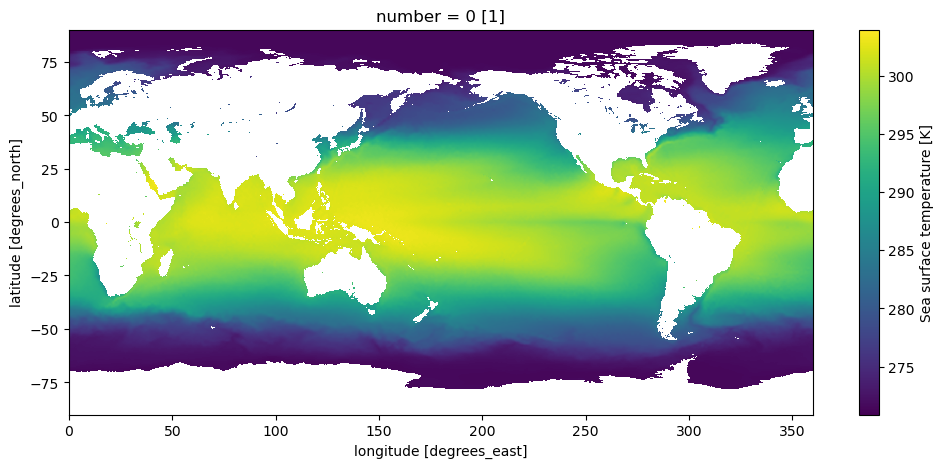

In [16]:
# Plot the mean sst 
sst_avg.plot()

In [19]:
# Try what happens if you don't specify the dimension for your averaging. 
ds.sst.mean().values

array(286.8429, dtype=float32)

**Q: What do you think happened?**

In [ ]:
# Try averaging SST over two dimensions (e.g. latitude and longitude). What kind of plot will this generate? 

*Note: scalar output is quite verbose in xarray... Your can print just the data onto the screen with the  .values attribute:*

In [ ]:
ds.sst.mean().values

**Q: what should we expect from the folowing commands:**

    ds.sst.mean(dim='longitude')
    ds.sst.mean(dim='valid_time').mean(dim='longitude')
    ds.sst.mean(dim=['valid_time', 'longitude'])
    
**Try them out!**

In [ ]:
# Try the commands above. Do they work as expected? 


**E: what is the maximum SST value? And the minimum?** ([hint](http://xarray.pydata.org/en/stable/generated/xarray.DataArray.min.html))

In [ ]:
# your answer here

## Slicing Data 

Sometimes, we want to focus on a certain region or period within our dataset, which means that we want to look at a _slice_ of the total array.  _xarray_ allows us to select data on such a slice. See what is happening below.  

In [ ]:
sst_Australia = ds.sst.sel(valid_time='2000-06-01',longitude = slice(105,160),latitude =slice(-8,-45))
sst_Australia

We can then make another plot. I am selecting a different map projection `LambertCylindrical()`, which looks better in this case. 
If you want to learn more about mapping and map projections you can read about them [here](https://earth-env-data-science.github.io/lectures/mapping_cartopy.html). 

In [ ]:
# Define the map projection (how does the map look like)
ax = plt.axes(projection=ccrs.LambertCylindrical())  #
# ax is an empty plot. We now plot the variable sst_jan onto ax
sst_Australia.plot(ax=ax, transform=ccrs.PlateCarree()) 
# the keyword "transform" tells the plotting function how to map the data onto a flat surface
ax.coastlines(); ax.gridlines(); # Add gridlines and coastlines to the plot